In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
import pickle
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split

In [187]:
with open("../data/03-result/merged_df.pkl","rb") as f:
    merged_df =pickle.load(f)

In [188]:
# Consider dropping name embedding similarity since it contains SPOILERS
merged_df = merged_df.drop(columns = ["name_similarity"])

# Fit models

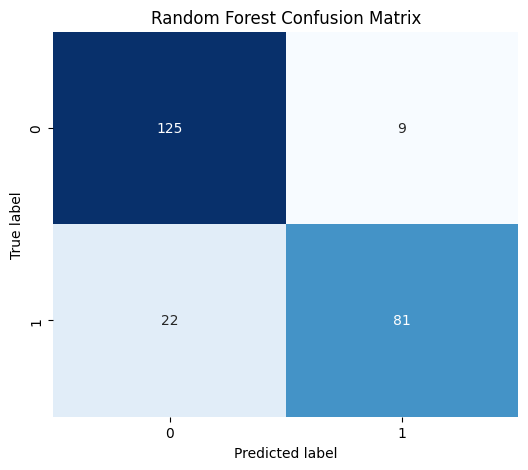

  Accuracy: 0.869198312236287
  Precision: 0.9
  Recall: 0.7864077669902912
  F1 score: 0.8393782383419689
  AUC: 0.9393566149833358


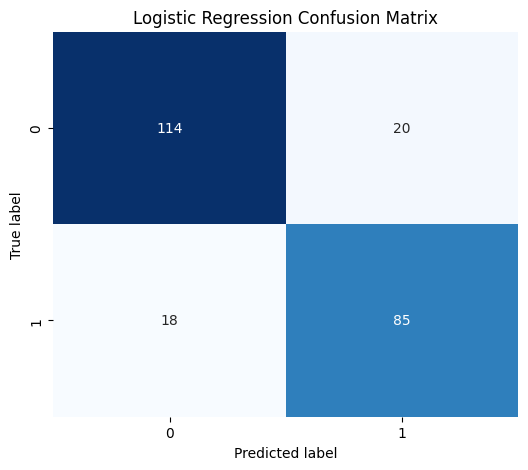

  Accuracy: 0.8396624472573839
  Precision: 0.8095238095238095
  Recall: 0.8252427184466019
  F1 score: 0.8173076923076923
  AUC: 0.8893638603101


In [209]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# ---------------------------------------
# 1. Split predictors / label
# ---------------------------------------
X = merged_df.drop(columns=["success", "drug_id","disease_id", "drug_name", "disease_name"])
y = merged_df["success"]

# Identify column types
num_cols = X.select_dtypes(include=["float64", "int64"]).columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns

# ---------------------------------------
# 2. Preprocessing pipelines
# ---------------------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

# ---------------------------------------
# 3. Models
# ---------------------------------------
rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("rf", RandomForestClassifier(class_weight='balanced',n_estimators=300, random_state=42))
])

logreg_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("logreg", LogisticRegression(class_weight='balanced', max_iter=500))
])

# ---------------------------------------
# 4. Train/test split
# ---------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------------------
# 5. Fit models
# ---------------------------------------
rf_model.fit(X_train, y_train)
logreg_model.fit(X_train, y_train)

# ---------------------------------------
# 6. Predictions
# ---------------------------------------
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

logreg_pred = logreg_model.predict(X_test)
logreg_proba = logreg_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

# ---------------------------------------
# 7. Evaluation
# ---------------------------------------

# TODO: balanced_accuracy score
# TODO: see wikipedian evalution metrics forbinary classification
# TODO: check imbalanced_learn module 


cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Random Forest Confusion Matrix')
plt.show()

print("  Accuracy:", accuracy_score(y_test, rf_pred))
print("  Precision:", precision_score(y_test, rf_pred))
print("  Recall:", recall_score(y_test, rf_pred))
print("  F1 score:", f1_score(y_test, rf_pred))
print("  AUC:", roc_auc_score(y_test, rf_proba))


cm = confusion_matrix(y_test, logreg_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Logistic Regression Confusion Matrix')
plt.show()
print("  Accuracy:", accuracy_score(y_test, logreg_pred))
print("  Precision:", precision_score(y_test, logreg_pred))
print("  Recall:", recall_score(y_test, logreg_pred))
print("  F1 score:", f1_score(y_test, logreg_pred))
print("  AUC:", roc_auc_score(y_test, logreg_proba))

In [198]:
import numpy as np

# Extract trained RF model inside the pipeline
rf = rf_model.named_steps["rf"]

# Get the transformed column names
num_features = list(num_cols)
cat_features = list(cat_cols)

# After transformation, numeric features stay single.
# Categorical features remain single because we didn't one-hot encode them.
all_features = num_features + cat_features

# Extract importances
importances = rf.feature_importances_

# Combine into one dataframe
rf_feature_importance = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values(by="importance", ascending=False)
rf_feature_importance

,feature,importance
222,path_similarity,0.031826
189,disease_path_17,0.024590
185,disease_path_13,0.022951
21,drug_path_2,0.022147
175,disease_path_3,0.021901
...,...,...
2,natural_product,0.000181
69,chirality__mixture,0.000145
5,veterinary,0.000009
71,chirality__nan,0.000000


In [199]:
logreg = logreg_model.named_steps["logreg"]

coef = logreg.coef_[0]   # Binary classification → one vector

logreg_feature_importance = pd.DataFrame({
    "feature": all_features,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values(by="abs_coef", ascending=False)

logreg_feature_importance

,feature,coef,abs_coef
66,drug_path_47,1.426687,1.426687
209,disease_path_37,-1.380253,1.380253
13,np_likeness_score,1.298258,1.298258
87,FP_16,-1.247606,1.247606
63,drug_path_44,1.147909,1.147909
...,...,...,...
55,drug_path_36,-0.014384,0.014384
146,FP_75,0.006065,0.006065
212,disease_path_40,-0.001776,0.001776
1,inorganic_flag,0.000000,0.000000


# TODO: PU / semi-supervized models 

# TODO: Graph models

In [192]:
# # TODO: explore GNN, node2vec ....
# from torch_geometric.data import HeteroData

# data = HeteroData()

# data['drug'].x = drug_features_tensor
# data['disease'].x = disease_features_tensor
# data['pathway'].x = pathway_dummy_features # can be zeros

# # Edges
# data['drug', 'interacts_with', 'pathway'].edge_index = drug_to_pathway_edges
# data['disease', 'associated_with', 'pathway'].edge_index = disease_to_pathway_edges

# # Now define a heterogeneous GNN
# model = HeteroGNN(...)

# # Training objective: predict edges between drug and disease
# # You give positive pairs (known therapeutic links) and negative pairs (random)